In [1]:
print("HELLO WORLD")

HELLO WORLD


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

import jax
import jax.numpy as jnp

import wavefunctions, trajectory, folx_hamiltonian

import importlib

In [3]:
jax.config.update("jax_enable_x64", True)

[0. 0. 0. 0. 0. 0. 0. 0.]


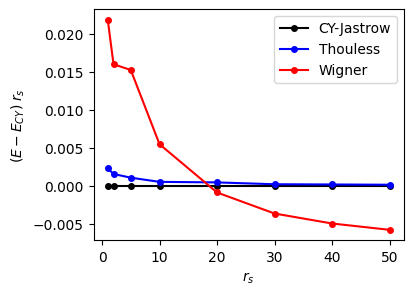

In [55]:
r_ws_list = np.array([1,2,5,10,20,30,40,50])
path = "thouless-test/{}/rs{}_best/{}"

cyjastrow = []
thouless = []
wigner = []

for r_ws in r_ws_list:
    cyjastrow.append(trajectory.getStatistics(
        path.format("CYJastrow", str(r_ws), "statistics.txt")
    ))
    thouless.append(trajectory.getStatistics(
        path.format("thouless", str(r_ws), "statistics.txt")
    ))
    wigner.append(trajectory.getStatistics(
        path.format("wigner", str(r_ws), "statistics.txt")
    ))

cyjastrow = np.array(cyjastrow)
thouless = np.array(thouless)
wigner = np.array(wigner)

def rescale(energies):
    return (energies - cyjastrow[:,0]) * r_ws_list

print(rescale(cyjastrow[:,0]))

plt.figure(figsize=(4,3))
plt.plot(
    r_ws_list, rescale(cyjastrow[:,0]),
    'o-', color='black', label='CY-Jastrow', markersize=4
)
plt.plot(
    r_ws_list, rescale(thouless[:,0]),
    'o-', color='blue', label='Thouless', markersize=4
)
plt.plot(
    r_ws_list, rescale(wigner[:,0]),
    'o-', color='red', label='Wigner', markersize=4
    )
plt.xlabel(f"$r_s$")
plt.ylabel(r"$(E - E_{CY}) \; r_s$")
plt.legend()
plt.show()

In [ ]:
r_ws_list = np.array([1,2,5,10,20,30,40,50])
path = "thouless-test/wigner/rs{}_best/parameters.msgpack"

N = 56
dim = 2
numKpoints = 169
spins = (N//2,N-N//2)

for r_ws in r_ws_list:

    lattice = wavefunctions.computeLattice(
        N, r_ws, dim, basis_matrix=jnp.array([[7,0],[0,4*jnp.sqrt(3)]])
    )
    kpoints = wavefunctions.genKpoints(numKpoints, lattice, dim)

    parameters = wavefunctions.loadParameters(path.format(r_ws))

    if 'MP_coefficients' in parameters['params']['slaterUp']:

        upCoeffs = parameters['params']['slaterUp']['MP_coefficients']
        downCoeffs = parameters['params']['slaterDown']['MP_coefficients']

    elif 'thouless_rotation' in parameters['params']['slaterUp']:

        upRotation = parameters['params']['slaterUp']['thouless_rotation']
        downRotation = parameters['params']['slaterDown']['thouless_rotation']

        upCoeffs = wavefunctions.occ_columns_from_theta(upRotation)
        downCoeffs = wavefunctions.occ_columns_from_theta(downRotation)

    Nk = kpoints.shape[0]
    cos = jnp.zeros(Nk).at[0].set(1.0)
    cos = cos.at[jnp.arange(1, Nk, 2)].set(1.0)
    cos_switch = cos
    sin_switch = 1.0 - cos

    def eval_basis_at_point(r):
        dot_vals = jnp.dot(kpoints, r)
        terms = cos_switch * jnp.cos(dot_vals) + sin_switch * jnp.sin(-dot_vals)
        return terms

    # 3. Generate Grid
    n_grid = 100
    u = jnp.linspace(0, 1, n_grid)
    v = jnp.linspace(0, 1, n_grid)
    uu, vv = jnp.meshgrid(u, v) 
    flat_frac = jnp.stack([uu.ravel(), vv.ravel()], axis=-1)
    flat_real = flat_frac @ lattice 

    # 4. Compute Densities
    # Evaluate basis: (N_grid, N_k)
    basis_vals = jax.vmap(eval_basis_at_point)(flat_real) 

    orbitals_up   = jnp.dot(basis_vals, upCoeffs)
    orbitals_down = jnp.dot(basis_vals, downCoeffs)

    rho_up   = jnp.sum(orbitals_up**2,   axis=1).reshape(n_grid, n_grid)
    rho_down = jnp.sum(orbitals_down**2, axis=1).reshape(n_grid, n_grid)

    # 5. Plot Side-by-Side
    # Grid coordinates for plotting
    grid_real = (jnp.stack([uu, vv], axis=-1) @ lattice)
    X_plot = grid_real[:, :, 0]
    Y_plot = grid_real[:, :, 1]

    # Determine global min/max for shared colorbar
    vmin = min(rho_up.min(), rho_down.min())
    vmax = max(rho_up.max(), rho_down.max())

    fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=120, constrained_layout=True)

    # Plot Up
    im1 = axes[0].pcolormesh(X_plot, Y_plot, rho_up, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[0].set_title(f"Spin-Up Density")
    axes[0].set_aspect('equal')
    axes[0].set_xlabel("x ($r_s$)")
    axes[0].set_ylabel("y ($r_s$)")

    # Plot Down
    im2 = axes[1].pcolormesh(X_plot, Y_plot, rho_down, shading='gouraud', cmap='viridis', vmin=vmin, vmax=vmax)
    axes[1].set_title(f"Spin-Down Density")
    axes[1].set_aspect('equal')
    axes[1].set_xlabel("x ($r_s$)")
    axes[1].set_yticks([]) # Hide Y ticks for the second plot

    # Shared Colorbar
    fig.suptitle(rf"$r_s = {r_ws}$", fontsize=14)
    fig.colorbar(im2, ax=axes, label="Electron Density", fraction=0.05, shrink=0.9)
    plt.show()

(169, 28) (169, 28)


Exception: 